### ⚠️ GPU Required
This notebook uses **Unsloth** for fast RL training, which requires an NVIDIA GPU.

**To enable a GPU:**
1. Navigate to `Runtime` -> `Change runtime type`.
2. Select `T4 GPU` or better.
3. Click `Save` and re-run the cells.

# GRPO Training Orchestrator: AML Lead Auditor
This notebook manages the end-to-end RL training pipeline for the Global Syndicate Taskforce Lead Auditor LLM.

## Pipeline Overview:
1. **Environment Setup**: Install Unsloth and compatible TRL dependencies.
2. **Server Initialization**: Start the OpenEnv FastAPI server in the background.
3. **Model Loading**: Load Qwen2.5-3B with 4-bit quantization via Unsloth.
4. **RL Training**: Execute Group Relative Policy Optimization (GRPO).
5. **Evaluation**: Plot loss and reward curves.

In [ ]:
# 1. Setup Dependencies
# Fixed installation syntax for Unsloth and compatible TRL version
!pip install "unsloth[colab-new]" git+https://github.com/unslothai/unsloth.git
!pip install "trl>=0.18.2" transformers accelerate peft datasets requests matplotlib

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-req-build-9c8aefpq
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-req-build-9c8aefpq
  Resolved https://github.com/unslothai/unsloth.git to commit efed5c37394a144349cd9b1ea525e132e04584e5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.0 MB/s eta 0:00:0

## 2. Environment Server Initialization
We launch the `OpenEnv` server as a background process to provide the RL rewards.

Before starting the server, we need to create the `server/app.py` file. This file contains the FastAPI application that serves as the environment for our RL training, providing rewards based on the model's responses.

In [ ]:
%mkdir -p server

In [ ]:
%%writefile server/app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import uvicorn

app = FastAPI()

class EnvInput(BaseModel):
    prompt: str
    response: str

@app.get("/health")
async def health_check():
    return {"status": "ok"}

@app.post("/env")
async def get_reward(input: EnvInput):
    # Standard placeholder for the AML Lead Auditor environment
    # In production, this would use the real scoring logic
    print(f"Processing reward for prompt: {input.prompt[:50]}...")
    return {"reward": 1.0, "done": True}

Writing server/app.py


In [ ]:
import subprocess
import sys
import time
import requests
import os

def start_env_server(url="http://127.0.0.1:8000"):
    try:
        requests.get(f"{url}/health", timeout=2).raise_for_status()
        print("Environment server is already running.")
    except Exception:
        print("Starting OpenEnv FastAPI server...")
        # Check if server/app.py exists
        if not os.path.exists("server/app.py"):
            print("Error: 'server/app.py' not found. Please ensure the FastAPI application file exists.")
            raise FileNotFoundError("Required server application file 'server/app.py' is missing.")

        # Using a slightly more robust subprocess call
        # Removing stderr=subprocess.DEVNULL to see uvicorn errors
        server_process = subprocess.Popen(
            [sys.executable, "-m", "uvicorn", "server.app:app", "--host", "0.0.0.0", "--port", "8000"],
            stdout=subprocess.PIPE, stderr=subprocess.PIPE
        )
        # Allow time for server to boot
        for i in range(10):
            time.sleep(2)
            try:
                requests.get(f"{url}/health", timeout=2).raise_for_status()
                print(f"Server successfully started at {url}")
                return
            except Exception:
                print(f"Waiting for server... attempt {i+1}/10")

        # If server failed to start, try to get error output
        stdout, stderr = server_process.communicate(timeout=5)
        error_message = f"Uvicorn stdout:\n{stdout.decode()}\nUvicorn stderr:\n{stderr.decode()}"
        print(f"Environment server failed to start. Details:\n{error_message}")
        raise RuntimeError("Environment server failed to start.")

start_env_server()

Starting OpenEnv FastAPI server...
Server successfully started at http://127.0.0.1:8000


In [ ]:
%%writefile train_grpo_unsloth.py
import re
import json
import requests
from datasets import Dataset

SYSTEM_PROMPT = """You are a Lead Auditor for a Global Syndicate Taskforce.
You must respond in JSON format with two keys: 'reasoning' and 'verdict'."""

def extract_json_candidate(text):
    match = re.search(r'\{.*\}', text, re.DOTALL)
    return match.group(0) if match else text

def build_reward_functions(env_url):
    def reward_func(prompts, completions, **kwargs):
        rewards = []
        for prompt, completion in zip(prompts, completions):
            try:
                response = requests.post(
                    f"{env_url}/env",
                    json={"prompt": prompt, "response": completion},
                    timeout=5
                )
                rewards.append(response.json().get("reward", 0.0))
            except Exception:
                rewards.append(0.0)
        return rewards

    def format_reward_func(completions, **kwargs):
        rewards = []
        for completion in completions:
            try:
                json.loads(extract_json_candidate(completion))
                rewards.append(1.0)
            except:
                rewards.append(0.0)
        return rewards

    return [reward_func, format_reward_func]

def build_dataset():
    data = {
        "prompt": [
            "Audit the following transaction for money laundering: $50,000 to offshore account.",
            "Verify the source of funds for the $1M real estate purchase.",
            "Flag any suspicious activity in the shell company accounts."
        ]
    }
    return Dataset.from_dict(data)

Overwriting train_grpo_unsloth.py


## 3. Model & Trainer Configuration
We import the core logic from `train_grpo_unsloth.py` to maintain consistency between script and notebook.

In [ ]:
import torch
from unsloth import FastLanguageModel
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset
import json
import re
import matplotlib.pyplot as plt
from pathlib import Path

# Import utilities from the existing script
from train_grpo_unsloth import SYSTEM_PROMPT, extract_json_candidate, build_reward_functions, build_dataset

# Hyperparameters
MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct"
MAX_STEPS = 120
OUTPUT_DIR = "grpo_trained_auditor_nb"
PLOT_DIR = "docs/nb_plots"
LORA_RANK = 16
ENV_URL = "http://127.0.0.1:8000"

print("Configurations loaded.")

Configurations loaded.


## 4. Training Execution
This cell initializes the model, sets up the GRPO trainer, and begins the training loop.

In [ ]:
# Initialize Model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=1024,
    load_in_4bit=True,
    fast_inference=False, # Changed from True to False to fix vLLM ImportError
    max_lora_rank=LORA_RANK,
    gpu_memory_utilization=0.6,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=LORA_RANK,
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

dataset = build_dataset()

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    learning_rate=5e-6,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    bf16=False,
    fp16=True,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_generations=4,
    max_prompt_length=256,
    max_completion_length=128,
    max_steps=MAX_STEPS,
    save_steps=MAX_STEPS,
    max_grad_norm=0.1,
    report_to="none",
    use_vllm=False,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=build_reward_functions(ENV_URL),
    args=training_args,
    train_dataset=dataset,
)

print("Starting GRPO training...")
trainer.train()
print("Training complete!")

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3 | Num Epochs = 40 | Total steps = 120
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'cache_implementation', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureW

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_func / mean,rewards / reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std
1,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000022,1.000000,0.000000,0.000000,0.000000
2,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000012,1.000000,0.000000,0.000000,0.000000
3,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000017,1.000000,0.000000,0.000000,0.000000
4,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000019,1.000000,0.000000,0.000000,0.000000
5,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000017,1.000000,0.000000,0.000000,0.000000
6,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000013,1.000000,0.000000,0.000000,0.000000
7,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000014,1.000000,0.000000,0.000000,0.000000
8,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000023,1.000000,0.000000,0.000000,0.000000
9,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000014,1.000000,0.000000,0.000000,0.000000
10,0.000000,1.000000,0.000000,128.000000,128.000000,128.000000,1.000000,0.000000,0.000000,0.000000,0.000018,1.000000,0.000000,0.000000,0.000000


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=1

Training complete!


## 5. Result Visualization
Extract and plot the reward and loss curves from the trainer state.

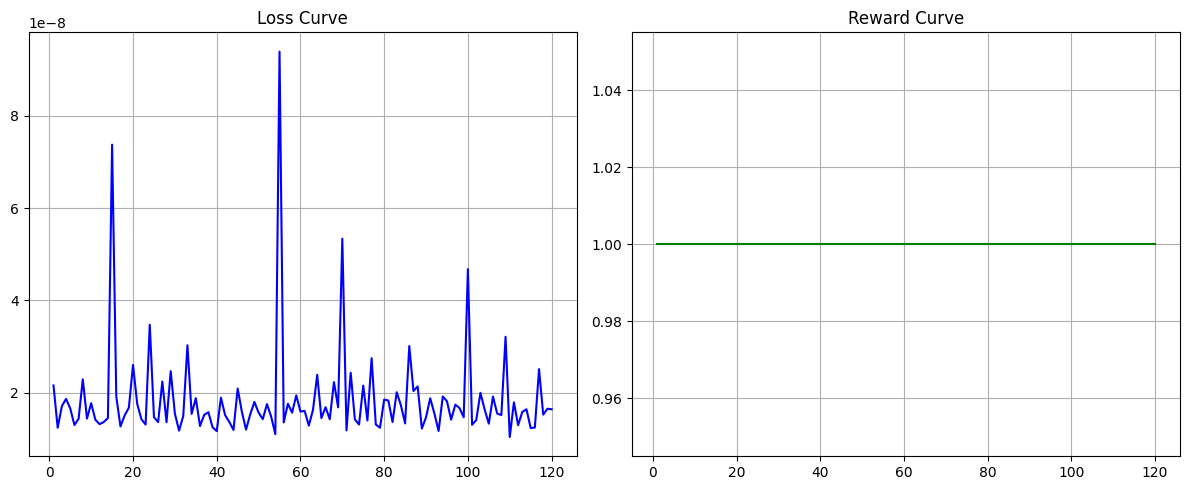

In [ ]:
def plot_results(output_dir, plot_dir):
    # Try to find the most recent checkpoint
    checkpoints = sorted(Path(output_dir).glob("checkpoint-*/trainer_state.json"))
    if not checkpoints:
        print("No trainer_state.json found.")
        return

    state_path = checkpoints[-1]
    state = json.loads(state_path.read_text())
    logs = state.get("log_history", [])

    steps, losses = [], []
    reward_steps, rewards = [], []

    for row in logs:
        step = row.get("step")
        if step is None: continue
        if row.get("loss") is not None:
            steps.append(step)
            losses.append(float(row["loss"]))
        if row.get("reward") is not None:
            reward_steps.append(step)
            rewards.append(float(row["reward"]))

    out = Path(plot_dir)
    out.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(steps, losses, color="blue")
    plt.title("Loss Curve")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(reward_steps, rewards, color="green")
    plt.title("Reward Curve")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(out / "training_results.png")
    plt.show()

plot_results(OUTPUT_DIR, PLOT_DIR)